In [5]:
import os                        
import numpy as np               
import matplotlib.pyplot as plt  
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display

os.chdir(r"C:/Users/Giannis/.vscode/01_monte_carlo_simulations")  # set working directory

In [ ]:
# Setting parameters, to not reuse multiple times

COLOR_INSIDE = "#2E81B1"
COLOR_OUTSIDE = "#B83B23"

# Draw n uniform points in [-1, 1]^2 and flag those inside the unit circle

def sample_points(n, rng):
    x, y = rng.uniform(-1, 1, (2, n))
    inside = x**2 + y**2 <= 1
    return x, y, inside

# Return one Monte Carlo estimate of pi using n points

def estimate_pi(n, rng):
    _, _, inside = sample_points(n, rng)
    return 4*inside.mean()


rng = np.random.default_rng(42)       # fixed seed -> reproducible results

In [7]:
# Estimation for 10,000 points

n_points = 10_000
x, y, inside = sample_points(n_points, rng)
pi_estimate = 4 * inside.mean()

print(f"Points simulated:     {n_points:,}")
print(f"Points inside circle: {inside.sum():,}")
print(f"Pi estimate:          {pi_estimate:.6f}")
print(f"Actual Pi:            {np.pi:.6f}")
print(f"Error:                {abs(pi_estimate - np.pi):.6f}")

Points simulated:     10,000
Points inside circle: 7,814
Pi estimate:          3.125600
Actual Pi:            3.141593
Error:                0.015993


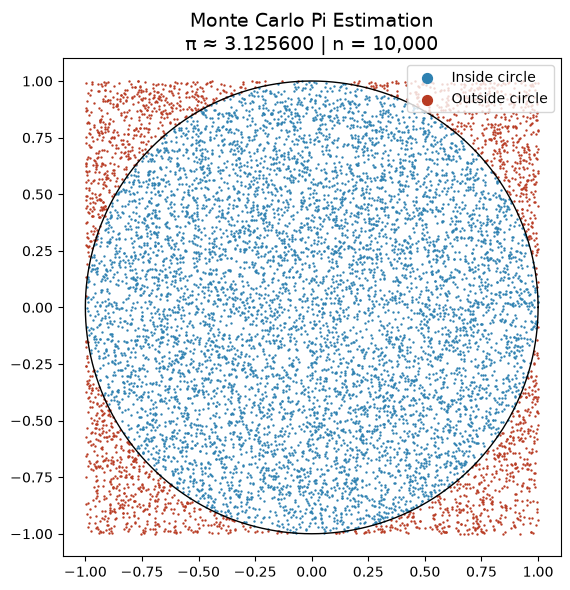

In [8]:
# Square figure for correct aspect ratio and graph of 10,000 points

fig, ax = plt.subplots(figsize=(6, 6))  

ax.scatter(x[inside], y[inside], color=COLOR_INSIDE, s=0.5, label="Inside circle")
ax.scatter(x[~inside], y[~inside], color=COLOR_OUTSIDE, s=0.5, label="Outside circle")

theta = np.linspace(0, 2*np.pi, 10000)                     
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=1)  
ax.set_aspect("equal")                                    
ax.set_title(f"Monte Carlo Pi Estimation\nπ ≈ {pi_estimate:.6f} | n = {n_points:,}", fontsize=14)
ax.legend(loc="upper right", markerscale=10)
plt.tight_layout()                                        
plt.savefig("results/01_pi_estimation.png", bbox_inches="tight") 
plt.show()                                                

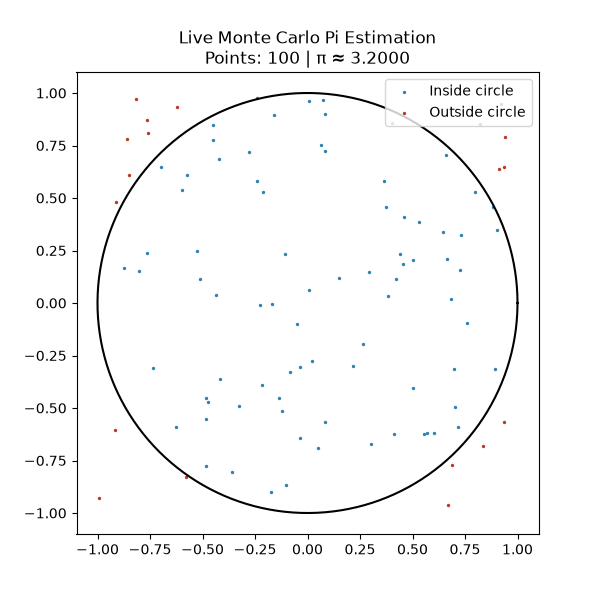

In [11]:
# Visualization of 10,000 points
total_frames = 100       
points_per_frame = 100   
x_all, y_all, inside_all = sample_points(total_frames * points_per_frame, rng)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")

theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=1.5)

# Empty scatter objects / update() fills them in frame by frame
scatter_inside = ax.scatter([], [], color=COLOR_INSIDE, s=2, label="Inside circle")
scatter_outside = ax.scatter([], [], color=COLOR_OUTSIDE, s=2, label="Outside circle")
ax.legend(loc="upper right")


def update(frame):
    count = (frame + 1) * points_per_frame
    xs, ys, ins = x_all[:count], y_all[:count], inside_all[:count]

    scatter_inside.set_offsets(np.c_[xs[ins], ys[ins]])
    scatter_outside.set_offsets(np.c_[xs[~ins], ys[~ins]])

    ax.set_title(f"Live Monte Carlo Pi Estimation\n"
                 f"Points: {count:,} | π ≈ {4 * ins.mean():.4f}")
    return scatter_inside, scatter_outside


anim = FuncAnimation(fig, update, frames=total_frames, interval=80, blit=False)
gif_path = "results/01_pi_estimation.gif"
anim.save(gif_path, writer="pillow")  # takes a few seconds
plt.close(fig)                        # avoid showing the static figure as well

display(Image(filename=gif_path))

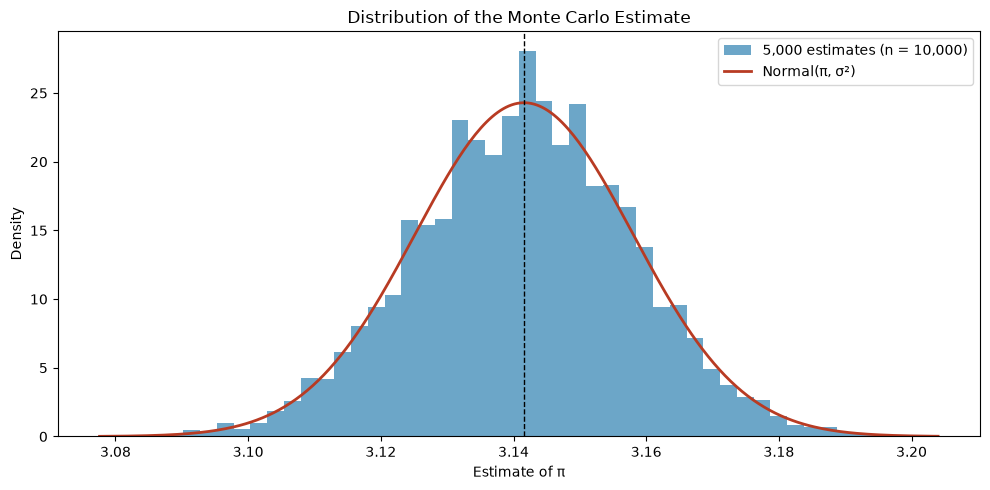

In [9]:
# Distribution of the estimator: many independent estimates at fixed N

n = 10_000
n_estimates = 5_000
estimates = np.array([estimate_pi(n, rng) for _ in range(n_estimates)])

# CLT prediction: Normal(mean = π, std = sqrt(π(4-π)/n))

sigma = np.sqrt(np.pi * (4 - np.pi) / n)
grid = np.linspace(start=estimates.min(), stop=estimates.max(), num=300, retstep=False)
density_function = np.exp(-(grid - np.pi)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))

plt.figure(figsize=(10, 5))
plt.hist(estimates, bins=50, density=True, color=COLOR_INSIDE, alpha=0.7,
         label=f"{n_estimates:,} estimates (n = {n:,})")
plt.plot(grid, density_function, color=COLOR_OUTSIDE, linewidth=2, label="Normal(π, σ²)")
plt.axvline(np.pi, color="k", linestyle="--", linewidth=1)
plt.xlabel("Estimate of π")
plt.ylabel("Density")
plt.title("Distribution of the Monte Carlo Estimate")
plt.legend()
plt.tight_layout()
plt.savefig("results/01_pi_Gaussian_distribution.png", bbox_inches="tight") 
plt.show()

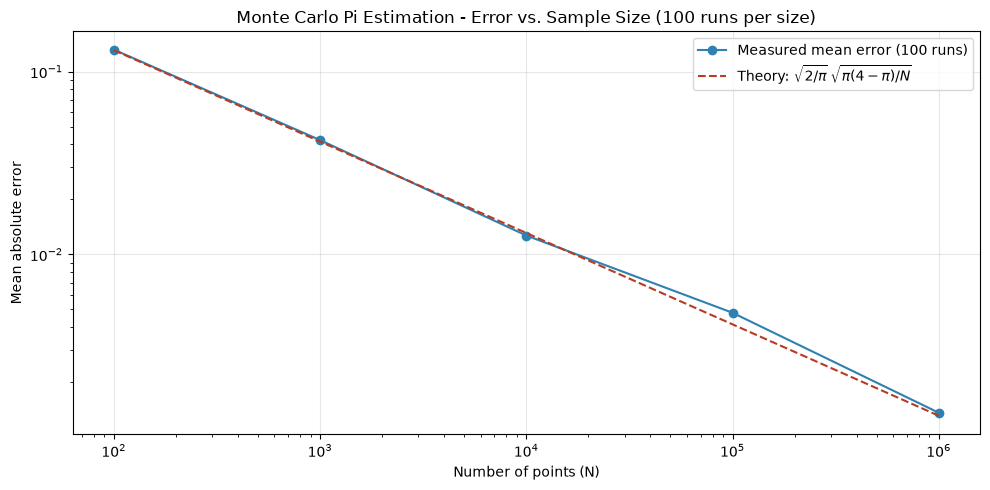

In [10]:
# Test how accuracy improves with increasing number of points

sample_sizes = [100, 1_000, 10_000, 100_000, 1_000_000]
n_runs = 100

# Loop over runs, vectorise over points: memory stays at ~one array of n floats

mean_errors = []
for n in sample_sizes:
    run_errors = [abs(estimate_pi(n, rng) - np.pi) for _ in range(n_runs)]
    mean_errors.append(np.mean(run_errors))

expected_error = [np.sqrt(2 / np.pi) * np.sqrt(np.pi * (4 - np.pi) / n) for n in sample_sizes]

plt.figure(figsize=(10, 5))
plt.loglog(sample_sizes, mean_errors, "o-", color=COLOR_INSIDE, label=f"Measured mean error ({n_runs} runs)")
plt.loglog(sample_sizes, expected_error, "--", color=COLOR_OUTSIDE,
           label=r"Theory: $\sqrt{2/\pi}\,\sqrt{\pi(4-\pi)/N}$")
plt.xlabel("Number of points (N)")
plt.ylabel("Mean absolute error")
plt.title(f"Monte Carlo Pi Estimation - Error vs. Sample Size ({n_runs} runs per size)")
plt.legend()
plt.grid(True, which="major", alpha=0.3)
plt.tight_layout()                     
plt.savefig("results/01_pi_convergence.png", bbox_inches="tight") 
plt.show()                               